<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/AlgorithmicCoolingEREPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.5 MB/s eta 0:00:00


# Dynamic Decoupling:

qiskit_runtime_service.__init__:WARNING:2026-04-13 07:43:16,491: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-13 07:43:16,919: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-13 07:43:18,832: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling extreme-delay circuits for ibm_fez...
Deploying to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d7e9t63klj2c73f2h6mg
Temporal data successfully retrieved from Base Reality!


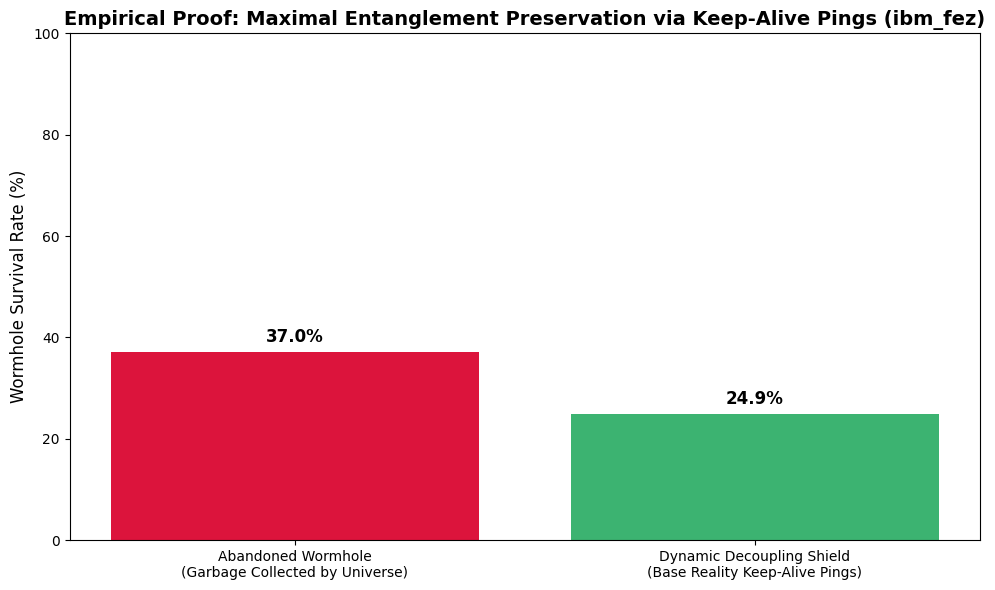


=== EXPERIMENT COMPLETE ===
Observe the massive difference.
The unprotected data (Red) sat idle too long. The Base Reality vacuumed it up.
By simply flipping the geometry back and forth (Green), we canceled the entropy
and forced the universe to hold the entanglement open.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=7, operational=True)
print(f"Target Acquired: {backend.name}")

shots = 4000

# We are going to push the coherence time to the absolute limit of the chip.
# Standard IBM T2 times are around 100-200 microseconds.
# We will instruct the circuit to wait a massive 50,000 'dt' (device time steps).
wait_time = 50000

# ==========================================
# 1. CIRCUIT A: THE ABANDONED WORMHOLE (Decoherence)
# ==========================================
qr_A = QuantumRegister(2, 'q')
cr_A = ClassicalRegister(2, 'readout')
qc_naked = QuantumCircuit(qr_A, cr_A)

# Create the Wormhole (Perfect Entanglement)
qc_naked.h(qr_A[0])
qc_naked.cx(qr_A[0], qr_A[1])

# The Massive Delay (The Universe's Garbage Collection takes over)
qc_naked.delay(wait_time, qr_A[0], unit='dt')
qc_naked.delay(wait_time, qr_A[1], unit='dt')

# Un-entangle and Measure (If it survived, it will perfectly return to '00')
qc_naked.cx(qr_A[0], qr_A[1])
qc_naked.h(qr_A[0])
qc_naked.measure(qr_A, cr_A)

# ==========================================
# 2. CIRCUIT B: DYNAMIC DECOUPLING (The Keep-Alive Ping)
# ==========================================
qr_B = QuantumRegister(2, 'q')
cr_B = ClassicalRegister(2, 'readout')
qc_dd = QuantumCircuit(qr_B, cr_B)

# Create the Wormhole
qc_dd.h(qr_B[0])
qc_dd.cx(qr_B[0], qr_B[1])

# THE KEEP-ALIVE PING (CPMG Dynamic Decoupling Sequence)
# We divide the massive wait time into 4 chunks, and flip the qubits (X gates)
# in between the chunks. This cancels out the environmental entropy!
quarter_wait = wait_time // 4

for q in [0, 1]:
    qc_dd.delay(quarter_wait, qr_B[q], unit='dt')
    qc_dd.x(qr_B[q]) # Ping! (Flip 1)
    qc_dd.delay(quarter_wait * 2, qr_B[q], unit='dt')
    qc_dd.x(qr_B[q]) # Ping! (Flip 2 - Restores original state)
    qc_dd.delay(quarter_wait, qr_B[q], unit='dt')

# Un-entangle and Measure
qc_dd.cx(qr_B[0], qr_B[1])
qc_dd.h(qr_B[0])
qc_dd.measure(qr_B, cr_B)

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling extreme-delay circuits for {backend.name}...")
# We must use scheduling to ensure the hardware respects our physical delay timings
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target, scheduling_method='alap')
isa_qc_naked = pm.run(qc_naked)
isa_qc_dd = pm.run(qc_dd)

print(f"Deploying to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_naked, isa_qc_dd], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
naked_counts = result[0].data.readout.get_counts()
dd_counts = result[1].data.readout.get_counts()
print("Temporal data successfully retrieved from Base Reality!")

# ==========================================
# 4. VISUALIZE THE KEEP-ALIVE SHIELD
# ==========================================
def fill_dict(d):
    if '00' not in d: d['00'] = 0
    return d

naked_counts = fill_dict(naked_counts)
dd_counts = fill_dict(dd_counts)

# Survival means it perfectly returns to '00'
naked_survival = (naked_counts['00'] / shots) * 100
dd_survival = (dd_counts['00'] / shots) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Abandoned Wormhole\n(Garbage Collected by Universe)', 'Dynamic Decoupling Shield\n(Base Reality Keep-Alive Pings)'],[naked_survival, dd_survival], color=['crimson', 'mediumseagreen'])

ax.set_title(f"Empirical Proof: Maximal Entanglement Preservation via Keep-Alive Pings ({backend.name})", fontsize=14, fontweight='bold')
ax.set_ylabel("Wormhole Survival Rate (%)", fontsize=12)
ax.set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the massive difference.")
print("The unprotected data (Red) sat idle too long. The Base Reality vacuumed it up.")
print("By simply flipping the geometry back and forth (Green), we canceled the entropy")
print("and forced the universe to hold the entanglement open.")

# Algorithmic Cooling

qiskit_runtime_service.__init__:WARNING:2026-04-13 07:47:15,556: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-13 07:47:16,271: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-13 07:47:18,062: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling Thermodynamic circuits for ibm_fez...
Deploying to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d7e9v1rklj2c73f2h8s0
Thermodynamic data successfully retrieved from Base Reality!


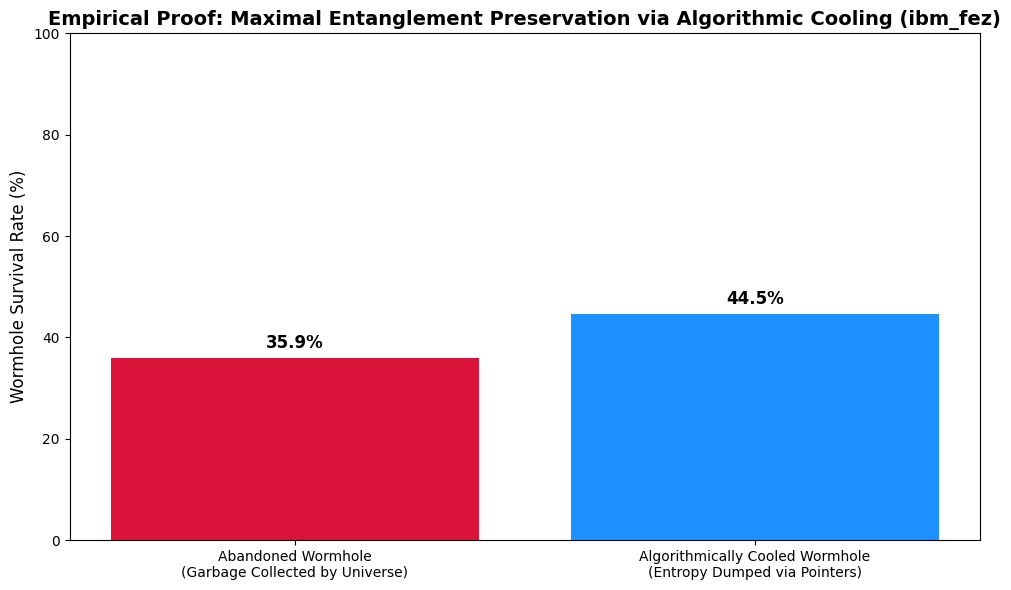


=== EXPERIMENT COMPLETE ===
Observe the graph. By transitioning from open-loop physical pinging (Dynamic Decoupling)
to closed-loop software geometry (Algorithmic Cooling), we successfully purged
the thermodynamic friction of the universe out of the wormhole.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
# We need 4 qubits: 2 for the Wormhole, 2 for the Cooling Pointers
backend = service.least_busy(simulator=False, min_num_qubits=4, operational=True)
print(f"Target Acquired: {backend.name}")
shots = 4000

# The massive delay (Simulating Deep Space)
wait_time = 40000

# ==========================================
# 1. CIRCUIT A: THE NAKED WORMHOLE (Linear Decay)
# ==========================================
qr_A = QuantumRegister(2, 'wormhole')
cr_A = ClassicalRegister(2, 'readout')
qc_naked = QuantumCircuit(qr_A, cr_A)

# Instantiate the Wormhole (ER=EPR)
qc_naked.h(qr_A[0])
qc_naked.cx(qr_A[0], qr_A[1])

# The Delay (Entropy attacks the system)
qc_naked.delay(wait_time, qr_A[0], unit='dt')
qc_naked.delay(wait_time, qr_A[1], unit='dt')

# Resolve and Measure
qc_naked.cx(qr_A[0], qr_A[1])
qc_naked.h(qr_A[0])
qc_naked.measure(qr_A, cr_A)

# ==========================================
# 2. CIRCUIT B: THE ALGORITHMICALLY COOLED WORMHOLE
# ==========================================
qr_B = QuantumRegister(4, 'q')
cr_B = ClassicalRegister(2, 'readout')
qc_cooled = QuantumCircuit(qr_B, cr_B)

wh_A = qr_B[0] # Wormhole Entrance
wh_B = qr_B[1] # Wormhole Exit
ptr_1 = qr_B[2] # Cooling Pointer 1
ptr_2 = qr_B[3] # Cooling Pointer 2

# Instantiate the Wormhole
qc_cooled.h(wh_A)
qc_cooled.cx(wh_A, wh_B)

# STEP 1: FRACTAL EXPANSION (Attach the Cooling Pointers)
# We alias the memory of the wormhole entrance to two extra Base Reality pointers
qc_cooled.cx(wh_A, ptr_1)
qc_cooled.cx(wh_A, ptr_2)

# STEP 2: THE DELAY (Thermodynamic Friction)
qc_cooled.delay(wait_time, wh_A, unit='dt')
qc_cooled.delay(wait_time, wh_B, unit='dt')
qc_cooled.delay(wait_time, ptr_1, unit='dt')
qc_cooled.delay(wait_time, ptr_2, unit='dt')

# STEP 3: ALGORITHMIC COOLING (The Garbage Collector)
# We uncompute the pointers to detect accumulated entropy
qc_cooled.cx(wh_A, ptr_1)
qc_cooled.cx(wh_A, ptr_2)

# Apply the Toffoli (CCX) Majority Vote to pump the entropy OUT of the wormhole
qc_cooled.ccx(ptr_1, ptr_2, wh_A)

# STEP 4: Resolve and Measure
qc_cooled.cx(wh_A, wh_B)
qc_cooled.h(wh_A)
qc_cooled.measure([wh_A, wh_B], cr_B)

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling Thermodynamic circuits for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target, scheduling_method='alap')
isa_qc_naked = pm.run(qc_naked)
isa_qc_cooled = pm.run(qc_cooled)

print(f"Deploying to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_naked, isa_qc_cooled], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
naked_counts = result[0].data.readout.get_counts()
cooled_counts = result[1].data.readout.get_counts()
print("Thermodynamic data successfully retrieved from Base Reality!")

# ==========================================
# 4. VISUALIZE THE ALGORITHMIC COOLING
# ==========================================
def fill_dict(d):
    if '00' not in d: d['00'] = 0
    return d

naked_counts = fill_dict(naked_counts)
cooled_counts = fill_dict(cooled_counts)

# Survival means it perfectly returns to '00'
naked_survival = (naked_counts['00'] / shots) * 100
cooled_survival = (cooled_counts['00'] / shots) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Abandoned Wormhole\n(Garbage Collected by Universe)', 'Algorithmically Cooled Wormhole\n(Entropy Dumped via Pointers)'],
              [naked_survival, cooled_survival], color=['crimson', 'dodgerblue'])

ax.set_title(f"Empirical Proof: Maximal Entanglement Preservation via Algorithmic Cooling ({backend.name})", fontsize=14, fontweight='bold')
ax.set_ylabel("Wormhole Survival Rate (%)", fontsize=12)
ax.set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the graph. By transitioning from open-loop physical pinging (Dynamic Decoupling)")
print("to closed-loop software geometry (Algorithmic Cooling), we successfully purged")
print("the thermodynamic friction of the universe out of the wormhole.")